# 01. 관광지수 EDA: 어디에 추천 자원을 집중할 것인가

## 비즈니스 질문

관광지는 단순 개수보다 **다양한 경험을 한 지역 안에서 제공할 수 있는가**가 중요하다.
따라서 행정동별 카테고리 분포와 엔트로피를 확인해, 여행 일정 구성에 유리한 지역을 찾고, 총량과 다양성 사이의 트레이드오프를 확인한다.

## 왜 이 계산법을 썼나

- `카테고리별 점수`: 힐링/액티비티/문화/음식/쇼핑/숙박 중 어떤 강점이 있는지 설명 가능하다.
- `엔트로피`: 특정 카테고리에만 치우치지 않고 다양한 경험을 제공하는지를 수치화한다.
- `표준편차`: 카테고리 편중이 큰 지역을 찾아 보완 기준으로 사용한다.




In [1]:
from pathlib import Path
import sys, os, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# matplotlib 캐시는 이 EDA 폴더 안에만 만들도록 고정한다.
MPL_CACHE_DIR = Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure/Business_Impact_EDA/.matplotlib_cache')
MPL_CACHE_DIR.mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(MPL_CACHE_DIR))

import matplotlib
if 'ipykernel' not in sys.modules:
    matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'Business_Impact_EDA' else Path(r'C:/Users/hyunj/Seoul_Strolling_Adventure')

# 노트북/Colab/로컬 환경에서 한글 폰트가 깨지지 않도록 설정
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
    get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'retina'")
except Exception:
    pass

import os
import shutil
import subprocess
import matplotlib as mpl
from matplotlib import font_manager as fm

# Colab/Linux 계열이면 나눔/Noto CJK 폰트 설치를 시도한다.
# Windows 로컬에서는 apt-get이 없으므로 설치를 건너뛰고 Malgun Gothic을 우선 사용한다.
if shutil.which('apt-get'):
    try:
        subprocess.run(['apt-get', 'update', '-qq'], check=False)
        subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum', 'fonts-nanum-extra', 'fonts-noto-cjk'],
                       check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    except Exception as e:
        print('폰트 설치 단계 건너뜀:', e)

# 캐시 삭제 & 폰트 매니저 재로딩
try:
    shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)
    Path(mpl.get_cachedir()).mkdir(parents=True, exist_ok=True)
    fm._load_fontmanager(try_read_cache=False)
except Exception as e:
    print('폰트 캐시 초기화 단계 건너뜀:', e)

# 우선순위: Colab/Linux용 나눔바른고딕 > 나눔고딕 > Noto CJK > Windows 맑은 고딕
candidates = ['NanumBarunGothic', 'NanumGothic', 'Noto Sans CJK KR', 'Malgun Gothic', 'AppleGothic']
avail = {name: any(name in font.name for font in fm.fontManager.ttflist) for name in candidates}
chosen = next((name for name in candidates if avail.get(name)), 'DejaVu Sans')

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = [chosen]
plt.rcParams['axes.unicode_minus'] = False
print('Using font:', chosen)

def read_csv(path, **kwargs):
    for enc in ['utf-8-sig', 'utf-8', 'cp949']:
        try:
            return pd.read_csv(path, encoding=enc, **kwargs)
        except UnicodeDecodeError:
            continue
    return pd.read_csv(path, **kwargs)

def find_csv_by_cols(folder, required_cols):
    for p in sorted(Path(folder).rglob('*.csv')):
        try:
            cols = set(read_csv(p, nrows=0).columns)
            if set(required_cols).issubset(cols):
                return p
        except Exception:
            pass
    raise FileNotFoundError(f'{folder} 안에서 컬럼 {required_cols}를 가진 csv를 찾지 못했습니다.')

def pct(a, b):
    if b == 0 or pd.isna(b):
        return np.nan
    return (a - b) / b * 100

DATA = {
    'ui_places': find_csv_by_cols(PROJECT_ROOT / 'UI', ['title', 'tour_score', 'review_score']),
    'congestion': find_csv_by_cols(PROJECT_ROOT / 'UI' / 'congestion_level', ['시간대', 'final_level']),
    'tourism_index': next(PROJECT_ROOT.rglob('final_data_Tourism.csv')),
    'popularity': PROJECT_ROOT / 'EDA' / 'popularity' / 'popularity_result.csv',
    'reviews': PROJECT_ROOT / 'EDA' / 'popularity' / 'zb_review_data_final.csv',
}

print('PROJECT_ROOT =', PROJECT_ROOT)
print('사용 데이터 존재 여부')
for k, v in DATA.items():
    print(f'{k:15s}: {v.exists()} | {v.relative_to(PROJECT_ROOT)}')






Using font: NanumGothic
PROJECT_ROOT = c:\Users\hyunj\Seoul_Strolling_Adventure
사용 데이터 존재 여부
ui_places      : True | UI\관광지_법정동_매핑결과.csv
congestion     : True | UI\congestion_level\혼잡도 최종등급_전국.csv
tourism_index  : True | EDA\관광지수\final_data_Tourism.csv
popularity     : True | EDA\popularity\popularity_result.csv
reviews        : True | EDA\popularity\zb_review_data_final.csv


In [2]:
tour = read_csv(DATA['tourism_index'])
category_cols = [c for c in ['힐링','액티비티','문화','음식','쇼핑','숙박'] if c in tour.columns]
tour['total_tour_score'] = tour[category_cols].sum(axis=1)
tour['dominant_category'] = tour[category_cols].idxmax(axis=1)
tour['dominant_share'] = tour[category_cols].max(axis=1) / tour['total_tour_score'].replace(0, np.nan)
tour['balanced_experience_score'] = tour['total_tour_score'] * tour['체험다양성_엔트로피'].fillna(0)

top_total = tour.nlargest(15, 'total_tour_score')
top_balanced = tour.nlargest(15, 'balanced_experience_score')
summary = pd.Series({
    '행정동 수': len(tour),
    '평균 관광 총점': tour['total_tour_score'].mean(),
    '상위 10% 기준 관광 총점': tour['total_tour_score'].quantile(.9),
    '평균 체험다양성 엔트로피': tour['체험다양성_엔트로피'].mean(),
    '편중도 평균': tour['dominant_share'].mean(),
})
summary


행정동 수              1100.000000
평균 관광 총점             12.421747
상위 10% 기준 관광 총점      21.016406
평균 체험다양성 엔트로피         1.258959
편중도 평균                0.505202
dtype: float64

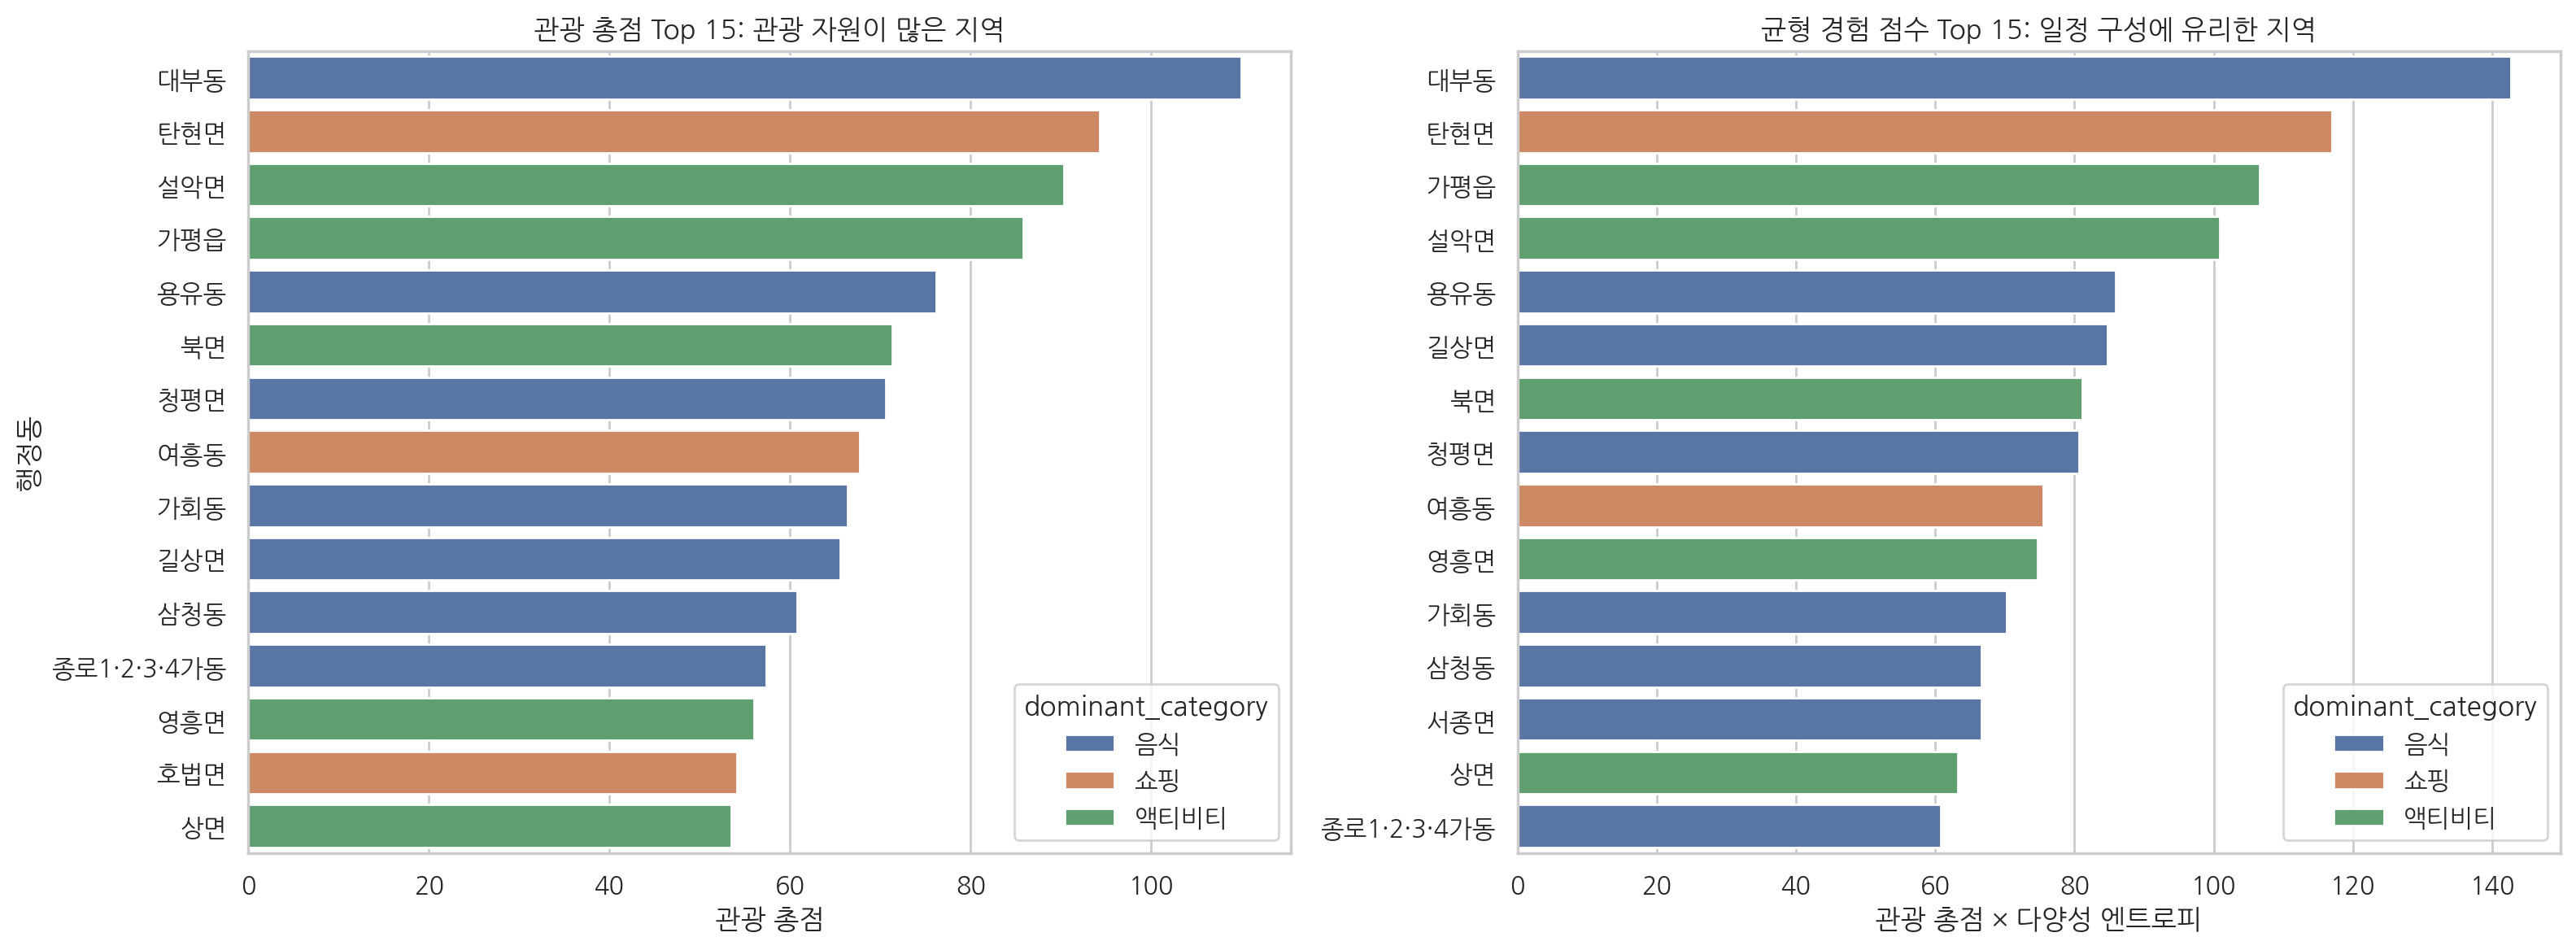

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=top_total, y='행정동', x='total_tour_score', hue='dominant_category', dodge=False, ax=axes[0])
axes[0].set_title('관광 총점 Top 15: 관광 자원이 많은 지역')
axes[0].set_xlabel('관광 총점')
axes[0].set_ylabel('행정동')

sns.barplot(data=top_balanced, y='행정동', x='balanced_experience_score', hue='dominant_category', dodge=False, ax=axes[1])
axes[1].set_title('균형 경험 점수 Top 15: 일정 구성에 유리한 지역')
axes[1].set_xlabel('관광 총점 × 다양성 엔트로피')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()



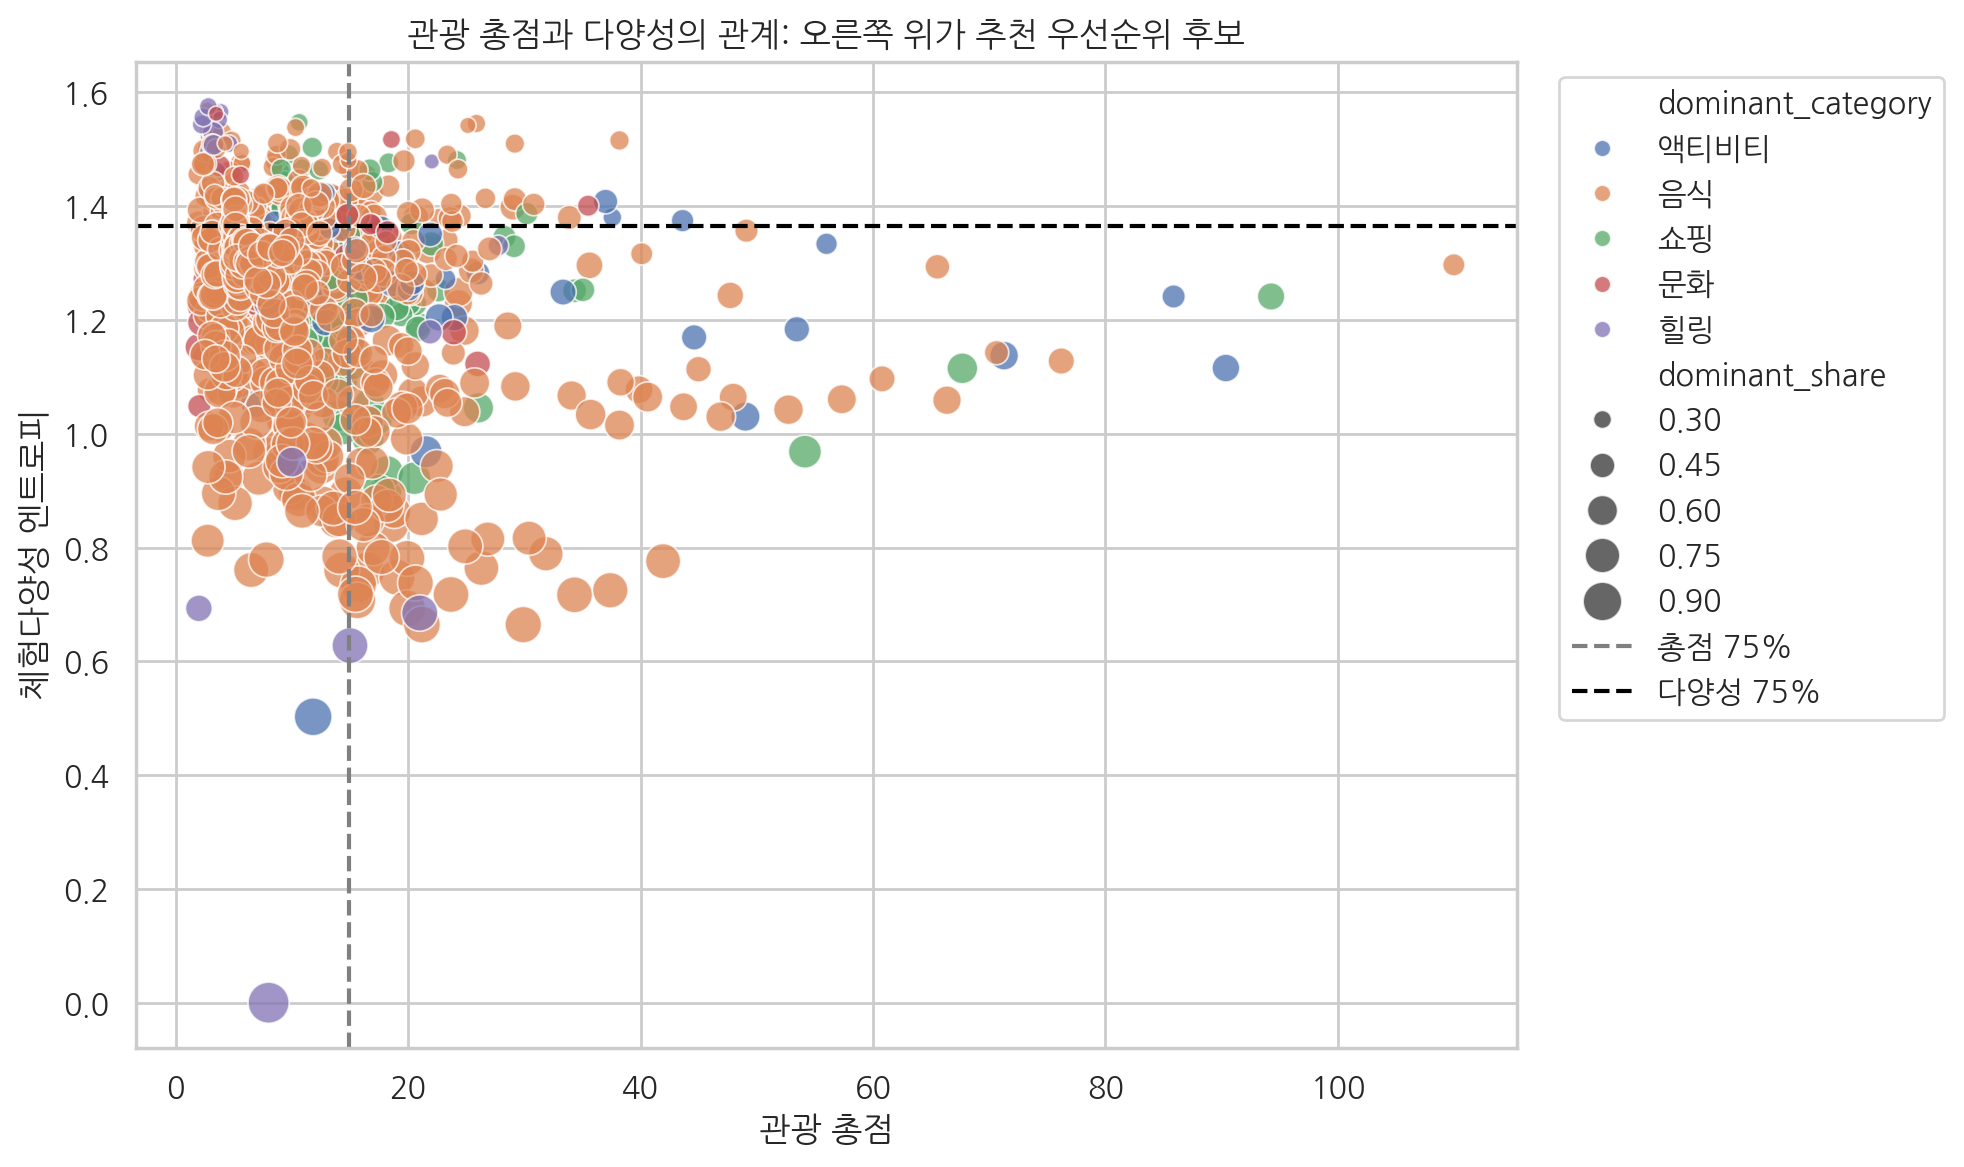

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=tour, x='total_tour_score', y='체험다양성_엔트로피', hue='dominant_category', size='dominant_share', sizes=(30, 220), alpha=.75, ax=ax)
ax.axvline(tour['total_tour_score'].quantile(.75), color='gray', linestyle='--', label='총점 75%')
ax.axhline(tour['체험다양성_엔트로피'].quantile(.75), color='black', linestyle='--', label='다양성 75%')
ax.set_title('관광 총점과 다양성의 관계: 오른쪽 위가 추천 우선순위 후보')
ax.set_xlabel('관광 총점')
ax.set_ylabel('체험다양성 엔트로피')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 검정: 다양성 상위 지역과 하위 지역의 관광 총점은 어떻게 다른가?

다양성 지표가 단순히 보기 좋은 지표인지, 혹은 관광 총점과 다른 의사결정 기준인지 Welch t-test로 확인한다. 결과가 음수라면 “다양성 높은 지역 = 관광 총량도 높다”가 아니라, 총량형 추천과 균형형 추천을 분리해야 한다는 근거로 해석한다.




In [5]:
high_div = tour[tour['체험다양성_엔트로피'] >= tour['체험다양성_엔트로피'].quantile(.75)]['total_tour_score']
low_div = tour[tour['체험다양성_엔트로피'] <= tour['체험다양성_엔트로피'].quantile(.25)]['total_tour_score']
t_stat, p_value = stats.ttest_ind(high_div, low_div, equal_var=False, nan_policy='omit')
lift = pct(high_div.mean(), low_div.mean())
print(f'상위 다양성 지역 평균 관광 총점: {high_div.mean():.2f}')
print(f'하위 다양성 지역 평균 관광 총점: {low_div.mean():.2f}')
print(f'차이: {lift:.1f}%')
print(f'Welch t-test p-value: {p_value:.4g}')
print('해석: 다양성 상위 지역은 관광 총량이 더 낮게 나타나므로, 총량 중심 추천과 균형 경험 중심 추천을 분리하는 것이 타당하다.')



상위 다양성 지역 평균 관광 총점: 10.79
하위 다양성 지역 평균 관광 총점: 16.10
차이: -33.0%
Welch t-test p-value: 2.68e-08
해석: 다양성 상위 지역은 관광 총량이 더 낮게 나타나므로, 총량 중심 추천과 균형 경험 중심 추천을 분리하는 것이 타당하다.


## 관광지수 한문장

관광지를 많이 보여주는 것이 아니라, 사용자가 하루 일정 안에서 여러 경험을 자연스럽게 조합할 수 있는 지역을 찾고자 했다. 그래서 카테고리별 점수와 엔트로피를 함께 사용했고, 다양성이 높은 지역이 관광 총점과 어떤 관계를 보이는지 통계 검정으로 확인했고, 총량 중심 추천과 균형 경험 중심 추천을 분리해야 한다는 근거로 삼았다.


